ДР 5. Группа 10. Обучение с учителем: Деревья решений. Хуснутдинов Эдуард Ринатович. Нуман Ахмед. Эспиноза Ортис Хуан Карлос

Дата: 03.04.2026



# Проверочный проект по моделям машинного обучения с учителем (supervised learning) - Методы на основе деревьев



## Этот проверочный проект можно выполнять тремя разными способами - мы обсуждаем это в видео-лекции с обзором проверочных заданий!

----

**Проверочный проект можно выполнять одним из трёх способов:**
   1. Открыть новый блокнот Jupyter Notebook, загрузить данные из файла - и далее самостоятельно выполнить анализ и визуализацию данных, а также создать предиктивную модель.
   2. Использовать блокнот с заданиями как общее руководство к действию, выполняя задания, написанные жирным шрифтом.
   3. Сразу перейти к блокноту с решениями и видео-лекциям с решениями, и параллельно с просмотром лекций выполнять эти задания в своём блокноте.

------
------

## ЦЕЛЬ: Создать модель предсказания того, уйдёт ли абонент в отток (churn).

----
----


## Выполните задания ниже, обозначенные жирным шрифтом!

## Часть 0: Импортируем библиотеки и загружаем данные

**Задание: Запустите уже готовые ячейки ниже, чтобы импортировать библиотеки и загрузить данные из файла в датафрейм. Файл называется "Telco-Customer-Churn.csv"**

In [1]:
# Запустите эти ячейки для начала выполнения проекта!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Часть 1: Общие характеристики данных

**Задание: С помощью метода .info() проверьте типы данных для колонок, а также есть ли отсутствующие значения в Вашем датафрейме.**

In [4]:
# Напишите Ваш код в этой ячейке
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

В данных нет пропусков. Типы данных - str, int, float

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


**Задание: Выведите статистические метрики для числовых колонок с помощью .describe(). Вы увидите, что большинство колонок являются категориальными, поэтому Вам позднее нужно будет создать для них дамми-переменные.**

In [5]:
# Напишите Ваш код в этой ячейке
df.select_dtypes(include='number').describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


# Часть 2:  Исследование данных (Exploratory Data Analysis)

## Исследование признаков

**Задание: Проверьте, что в этих данных нет отсутствующих значений - для этого выведите количество значений NaN отдельно для каждой колонки.**

In [9]:
# Напишите Ваш код в этой ячейке
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

NaN отсутствуют

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Задание: Постройте график CountPlot для проверки сбалансированности значений колонки с классами (Churn).**

<Axes: xlabel='Churn', ylabel='count'>

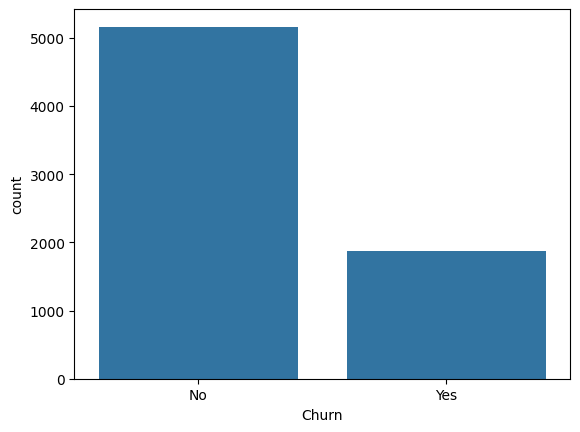

In [10]:
# Напишите Ваш код в этой ячейке
sns.countplot(x='Churn', data=df)

In [11]:
df.Churn.value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

Присутствует дисбаланс классов. Churn=Yes ~27% и Churn=No ~73%

<img src='fig1.png' >

**Задание: Исследуйте распределение колонки TotalCharges по различным категориям Churn с помощью графика Box Plot или Violin Plot.**

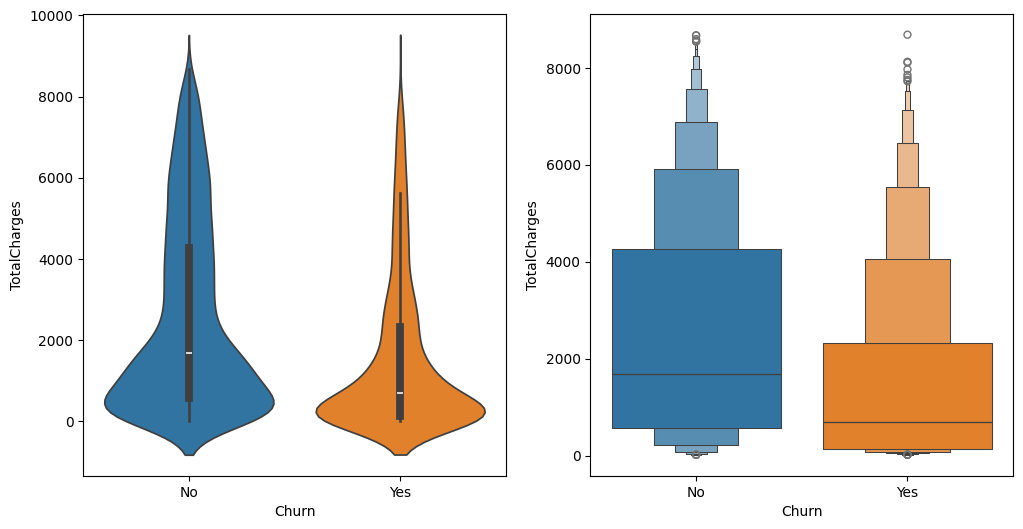

In [25]:
# Напишите Ваш код в этой ячейке
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.violinplot(
    data=df, x="Churn", y="TotalCharges", hue="Churn",
    inner="box", density_norm="width", legend=False,
    ax=axes[0],
)


sns.boxenplot(
    data=df, x="Churn", y="TotalCharges", hue="Churn",
    legend=False,
    ax=axes[1],
)


plt.show()

Churn=No: Распределение широкое и равномерное — клиенты платят от малого до очень большого 


Churn=Yes: Форма резко сужается кверху — подавляющее большинство ушедших клиентов заплатили мало

То есть ушедшие клиенты в основном новые (мало заплатили = короткий срок). Удержание особенно важно на старте.

<Axes: xlabel='Churn', ylabel='TotalCharges'>

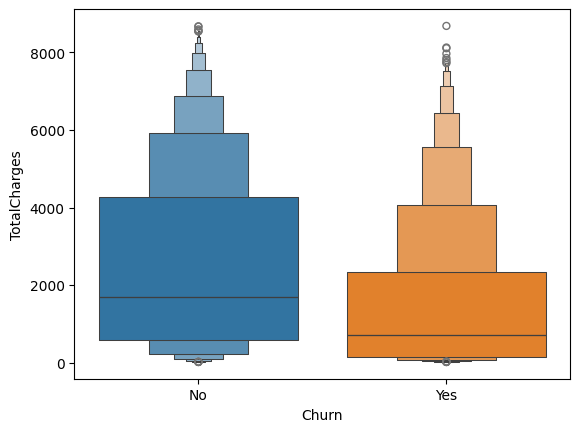

<img src='fig2.png' >

**Задание: Постройте график boxplot с распределением колонки TotalCharges для различных типов контрактов, а также добавьте раскраску цветами по колонке Churn.**

<Axes: xlabel='Contract', ylabel='TotalCharges'>

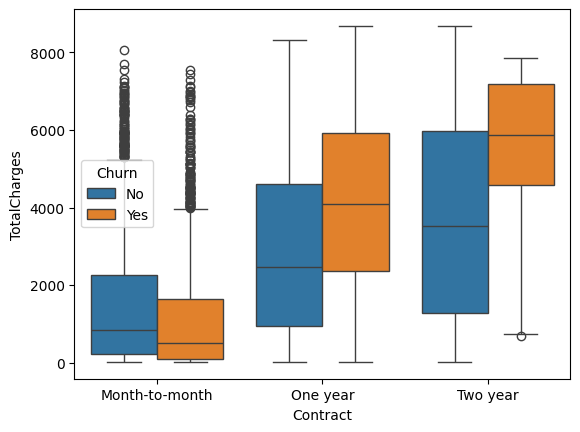

In [14]:
# Напишите Ваш код в этой ячейке
sns.boxplot(
    data=df,
    x="Contract",
    y="TotalCharges",
    hue="Churn",
)

Для групп `One year Contract` и `Two year` довольно заметно отличие в распределении TotalCharges. Для Churn=Yes значения TotalCharges заметно выше

<img src='fig3.png' >

**Задание: Постройте график barplot с корреляции указанных ниже признаков с целевой переменной. Обратите внимание, что для категориальных признаков сначала нужно сконвертировать их в дамми-переменные, потому что корреляция вычисляется только для числовых колонок.**

    ['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 
     'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

***Мы специально привели список признаков, чтобы не проверять все признаки. Дело в том, что некоторые признаки имеют слишком много уникальных значений для такого анализа, например колонка customerID.***

/var/folders/t1/m2tfv5zd73qfk8f49z94ln3m0000gn/T/ipykernel_49539/1439853220.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


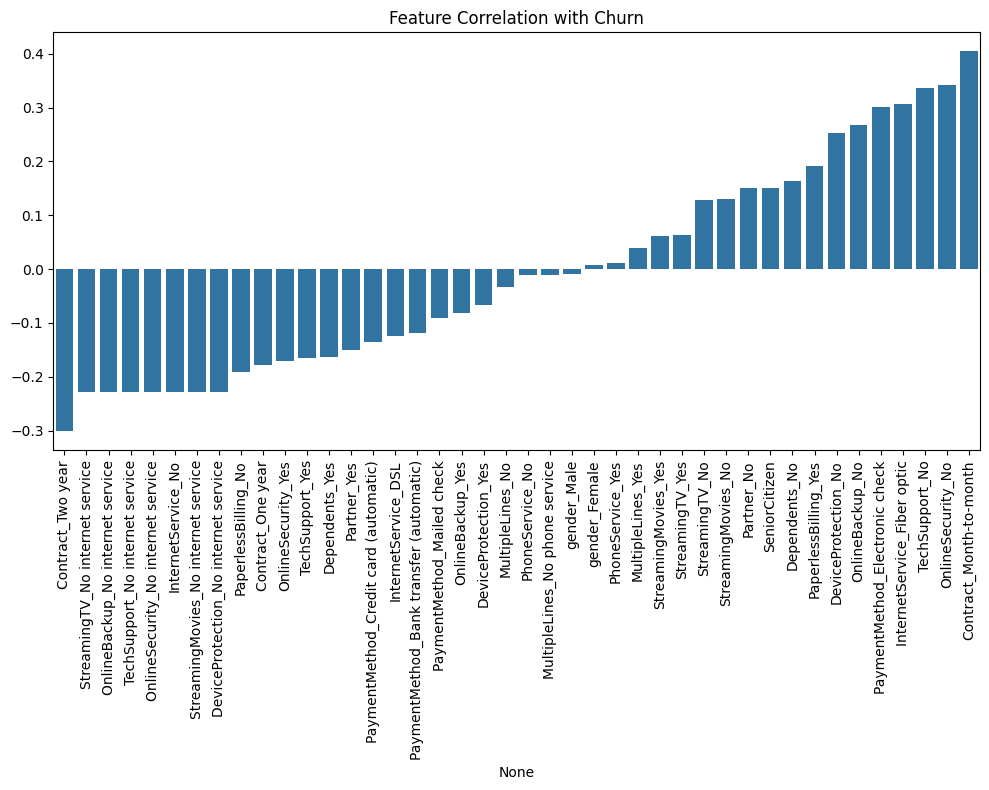

In [34]:
# Напишите Ваш код в этой ячейке

features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 
     'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

target = (df['Churn'] == 'Yes').astype(int)

dummies = pd.get_dummies(df[features])
corr = dummies.corrwith(target).sort_values()

fig, ax = plt.subplots(figsize=(10,8))

sns.barplot(y=corr.values, x=corr.index, ax=ax)

ax.set_title("Feature Correlation with Churn")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

In [33]:
corr

Contract_Two year                         -0.301552
StreamingTV_No internet service           -0.227578
OnlineBackup_No internet service          -0.227578
TechSupport_No internet service           -0.227578
OnlineSecurity_No internet service        -0.227578
InternetService_No                        -0.227578
StreamingMovies_No internet service       -0.227578
DeviceProtection_No internet service      -0.227578
PaperlessBilling_No                       -0.191454
Contract_One year                         -0.178225
OnlineSecurity_Yes                        -0.171270
TechSupport_Yes                           -0.164716
Dependents_Yes                            -0.163128
Partner_Yes                               -0.149982
PaymentMethod_Credit card (automatic)     -0.134687
InternetService_DSL                       -0.124141
PaymentMethod_Bank transfer (automatic)   -0.118136
PaymentMethod_Mailed check                -0.090773
OnlineBackup_Yes                          -0.082307
DeviceProtec

Contract_Two year                         -0.301552
StreamingMovies_No internet service       -0.227578
StreamingTV_No internet service           -0.227578
TechSupport_No internet service           -0.227578
DeviceProtection_No internet service      -0.227578
OnlineBackup_No internet service          -0.227578
OnlineSecurity_No internet service        -0.227578
InternetService_No                        -0.227578
PaperlessBilling_No                       -0.191454
Contract_One year                         -0.178225
OnlineSecurity_Yes                        -0.171270
TechSupport_Yes                           -0.164716
Dependents_Yes                            -0.163128
Partner_Yes                               -0.149982
PaymentMethod_Credit card (automatic)     -0.134687
InternetService_DSL                       -0.124141
PaymentMethod_Bank transfer (automatic)   -0.118136
PaymentMethod_Mailed check                -0.090773
OnlineBackup_Yes                          -0.082307
DeviceProtec

<img src='figbar.png'>

---
---

# Часть 3: Анализ оттока

**В этих заданиях мы выполним сегментацию абонентов на основе колонки tenure, создавая "когорты" и выполняя сравнение данных между различными когортами.**

**Задание: Перечислите 3 типа контракта (колонка Contract).**

In [35]:
# Напишите Ваш код в этой ячейке
df.Contract.unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

Контракты: 'Month-to-month', 'One year', 'Two year'

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

**Задание: Создайте гистограмму с распределением значений колонки tenure - это количество месяцев, сколько времени человек является (или являлся) абонентом компании.**

<Axes: xlabel='tenure', ylabel='Count'>

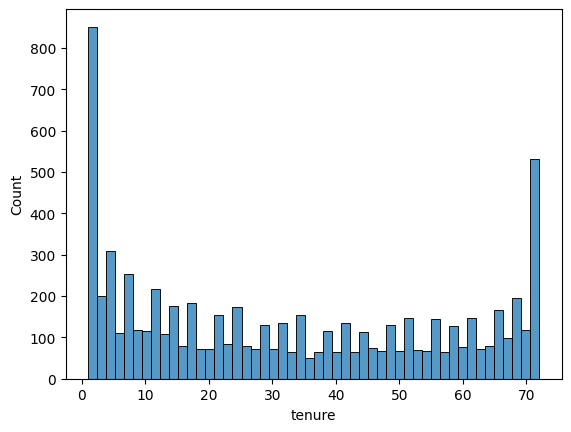

In [39]:
# Напишите Ваш код в этой ячейке
sns.histplot(data=df, x="tenure", bins=50)

<img src="fig5.png">

**Задание: Постройте гистограммы для колонки tenure, разбивая данные по двум колонкам - Churn и Contract. Посмотрите документацию по seaborn или блокноты для раздела про seaborn, чтобы вспомнить, как это делается.**

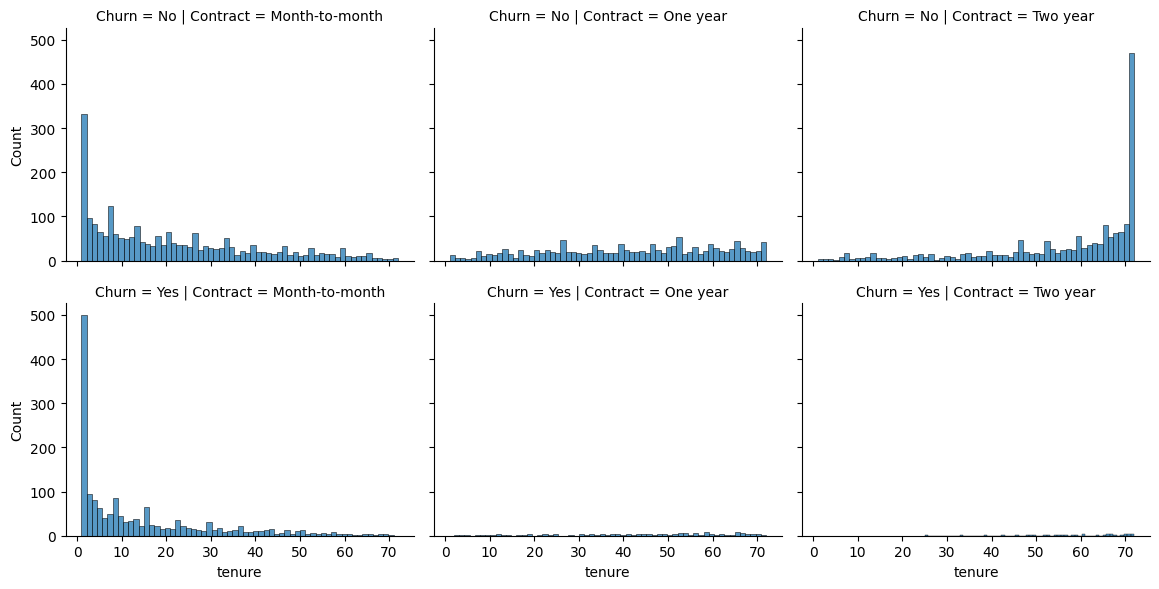

In [44]:
# Напишите Ваш код в этой ячейке
g = sns.FacetGrid(df, row="Churn", col="Contract", height=3, aspect=1.3)
g.map(sns.histplot, "tenure", bins=60)

plt.tight_layout()
plt.show()

<img src="fig6.png">

**Задание: Постройте график scatterplot для колонок Total Charges и Monthly Charges, раскрашивая график цветами по колонке Churn.**

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

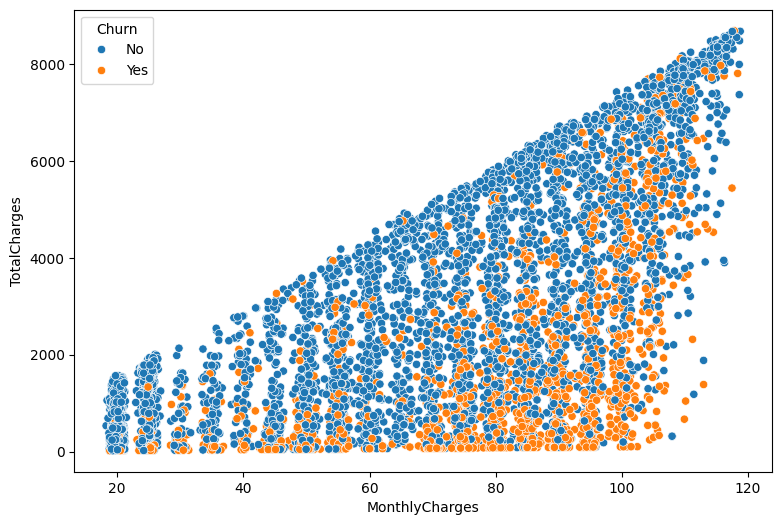

In [49]:
# Напишите Ваш код в этой ячейке

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="Churn",
    ax=ax
)

<img src='fig7.png'>

### Создание когорт (сегментов) по колонке Tenure

**Для начала поместим различные значения tenure (1 месяц, 2 месяца, 3 месяца и так далее) в отдельные когорты (сегменты).**

**Задание: Для каждого уникального значения колонки tenure в качестве когорты, вычислите процент оттока (churn rate) - это количество тех людей, кто ушёл в отток в когорте, как процент от общего количества людей в данной когорте. Вычислите такой процент отдельно для каждой когорты. Например, для когорты с tenure = "1 месяц" должен получиться процент оттока 61.99%. В итоге у Вас должны получиться когорты от 1 до 72 месяцев, и с увеличением количества месяцев уровень оттока должен снижаться. Это разумно, потому что чем дольше человек пользуется услугами компании, тем вероятнее то, что его/её всё устраивает, и он/она продолжит пользоваться этими услугами.**

In [53]:
# Напишите Ваш код в этой ячейке
cohorts = (
    df
    .groupby("tenure")["Churn"]
    .apply(
        lambda x: 100*(x == "Yes").sum() / len(x)
    )
)

cohorts

tenure
1     61.990212
2     51.680672
3     47.000000
4     47.159091
5     48.120301
        ...    
68     9.000000
69     8.421053
70     9.243697
71     3.529412
72     1.657459
Name: Churn, Length: 72, dtype: float64

tenure
1     61.990212
2     51.680672
3     47.000000
4     47.159091
5     48.120301
        ...    
68     9.000000
69     8.421053
70     9.243697
71     3.529412
72     1.657459
Name: customerID, Length: 72, dtype: float64

**Задание: Используя результаты предыдущего задания, постройте график процента оттока для различных значений tenure.**

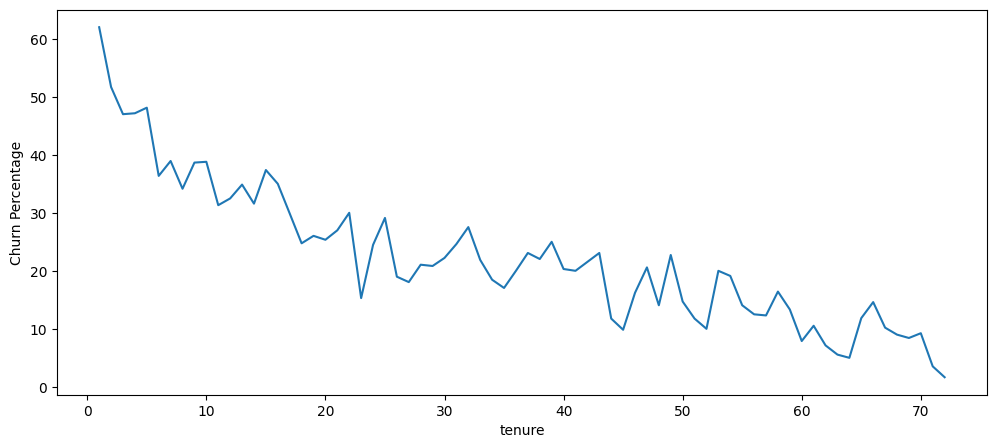

In [58]:
# Напишите Ваш код в этой ячейке
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(data=cohorts, ax=ax)
ax.set_ylabel("Churn Percentage")
plt.show()

<img src='fig9.png'>

### Более крупные когорты (сегменты)
**Задание: На основе колонки tenure создайте новую колонку с названием "Tenure Cohort", в которой будут следующие 4 категории:**
   * '0-12 месяцев'
   * '24-48 месяцев'
   * '12-24 месяцев'
   * 'Более 48 месяцев'    

In [65]:
# Напишите Ваш код в этой ячейке
def tenure_cohort(tenure):
    if tenure <= 12:
        return '0-12 Months'
    elif tenure <= 24:
        return '12-24 Months'
    elif tenure <= 48:
        return '24-48 Months'
    else:
        return 'Over 48 Months'

df['Tenure Cohort'] = df['tenure'].apply(tenure_cohort)

df[['tenure','Tenure Cohort']].head(10)

,tenure,Tenure Cohort
0,1,0-12 Months
1,34,24-48 Months
2,2,0-12 Months
3,45,24-48 Months
4,2,0-12 Months
5,8,0-12 Months
6,22,12-24 Months
7,10,0-12 Months
8,28,24-48 Months
9,62,Over 48 Months


,tenure,Tenure Cohort
0,1,0-12 Months
1,34,24-48 Months
2,2,0-12 Months
3,45,24-48 Months
4,2,0-12 Months
5,8,0-12 Months
6,22,12-24 Months
7,10,0-12 Months
8,28,24-48 Months
9,62,Over 48 Months


**Задание: Постройте график scatterplot для Total Charges и Monthly Charts, раскрашивая график разными цветами по колонке "Tenure Cohort", которую Вы создали в предыдущем задании.**

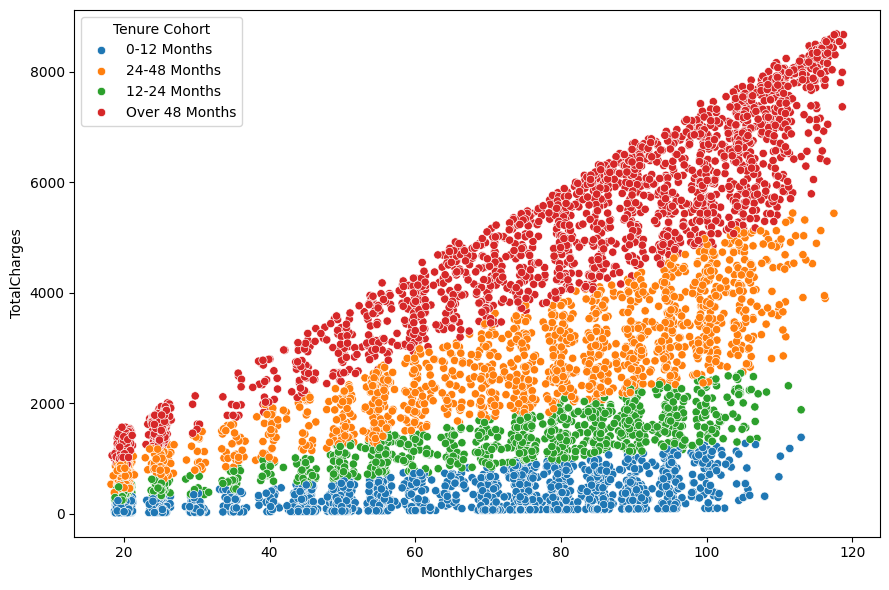

In [74]:
# Напишите Ваш код в этой ячейке
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="Tenure Cohort",
    ax=ax,
)


plt.tight_layout()
plt.show()

<img src='fig10.png'>

**Задание: Постройте график countplot с количеством ушедших и не ушедших в отток людей в каждой когорте.**

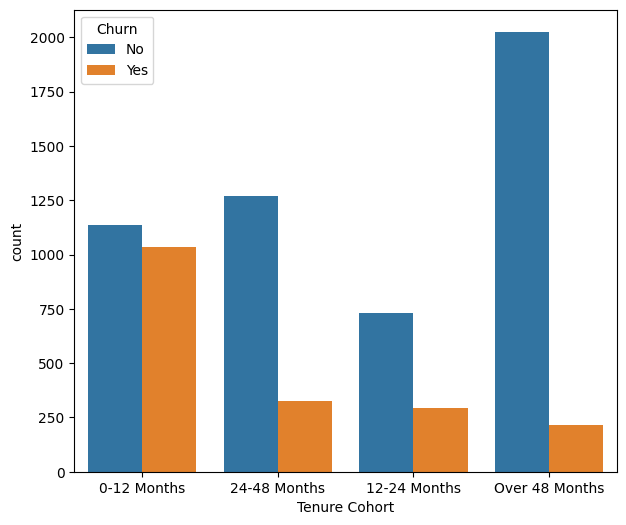

In [80]:
# Напишите Ваш код в этой ячейке
fig, ax = plt.subplots(figsize=(7, 6))

sns.countplot(
    data=df,
    x="Tenure Cohort",
    hue="Churn",
    ax=ax,
)

plt.show()

График показывает чёткую закономерность: чем дольше клиент пользуется услугами, тем реже уходит

- 0-12 Months — самая опасная когорта: ~1100 ушедших из 1100+1000, то есть почти каждый второй уходит в первый год. Oтток 52%
- 24-48 Months — ситуация улучшается: ~300 ушедших из ~300+1250. Oтток 19%
- 12-24 Months — похожая картина: ~300 ушедших из ~300+750 . Oтток 29%
- Over 48 Months — самая лояльная группа: ~220 ушедших из ~220+2000. Oтток 9%

Главный вывод: критический период — первые 12 месяцев. Если удержать клиента до 2+ лет, вероятность оттока падает до 9%. Усилия по retention имеет смысл концентрировать именно на новых клиентах.

<img src='cplot.png'>

**Задание: Создайте набор графиков CountPlot с количеством людей по различным когортам Tenure Cohort. Для каждого типа контракта создайте отдельный график, и раскрасьте эти графики разными цветами по колонке Churn.**

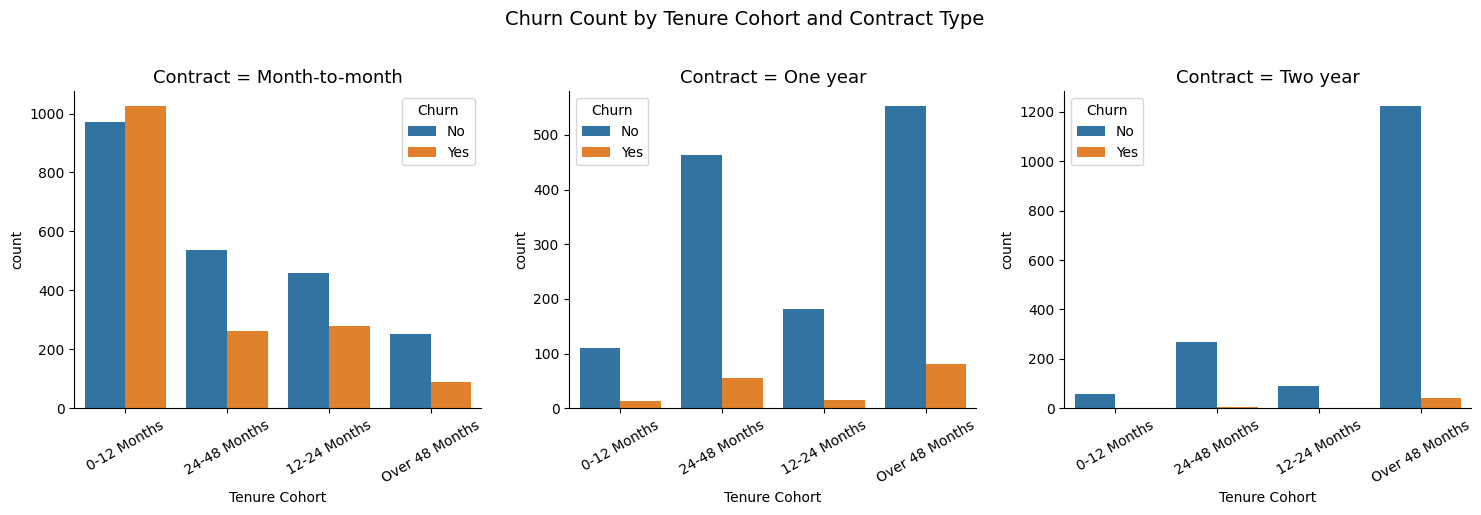

In [94]:
# Напишите Ваш код в этой ячейке
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

contracts = df["Contract"].unique()
order = df["Tenure Cohort"].unique().tolist()

for ax, contract in zip(axes, contracts):
    sns.countplot(
        data=df[df["Contract"] == contract],
        order=order,
        x="Tenure Cohort",
        hue="Churn",
        ax=ax,
    )
    ax.set_title('Contract = '+contract, fontsize=13)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Churn Count by Tenure Cohort and Contract Type", fontsize=14, y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

Month-to-month:

— самый ненадежный контракт: в когорте 0-12 месяцев ушедших даже больше, чем оставшихся. 
- С ростом tenure отток снижается, но остаётся заметным во всех когортах.



One year:

— картина значительно лучше: отток небольшой. 
- Большинство клиентов сосредоточены в 24-48 и Over 48.


Two year:

— практически нулевой отток во всех когортах. 
- Почти все клиенты находятся в Over 48 месяцев, оранжевые столбцы едва заметны.


Главный вывод: тип контракта — ключевой фактор удержания. Перевод клиенты с долгосрочным контрактами сильно снижает вероятность оттока. Особое внимание новым Month-to-month клиентам в первые 12 месяцев - именно там потери максимальны.

<img src='fig11.png'>

-----

# Часть 4: Предиктивная модель

**Давайте исследуем 4 модели на основе деревьев: одно дерево решений, случайный лес, адаптивный бустинг и градиентный бустинг. При желании Вы можете дополнительно попробовать любые другие модели машинного обучения с учителем (supervised learning models) и сравнить результаты!**


## Одно дерево решений (Decision Tree)

**Задание: Разделите все данные на признаки X и целевую переменную Y. Создайте дамми-переменные, где это необходимо, а также посмотрите, есть ли какие-то признаки, которые можно было бы удалить.**

In [97]:
# Напишите Ваш код в этой ячейке

X = df.drop(columns=["customerID", "Churn", "Tenure Cohort"])

X = pd.get_dummies(X)


y = (df["Churn"] == "Yes").astype(int)

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,True,False,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,False,True,True,False,True,False,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,False,True,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,False,True,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,True,False,True,False,True,False,...,False,True,False,False,False,True,False,False,True,False


**Задание: Выполните разбиение данных на обучающий и тестовый наборы (train test split), откладывая в сторону 10% данных для тестирования. В решениях мы используем random_state=101.**

In [98]:
# Напишите Ваш код в этой ячейке
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=101,
)

**Задание: Постройте модель Decision Tree и оцените её работу. Для этого выполните следующие шаги:**
   1. Обучите модель дерева решений (при желании можете выполнить поиск по сетке для поиска оптимальных значений гиперпараметров).
   2. Оцените метрики работы модели дерева решений - для этого выведите отчёт "classification report" и нарисуйте график с матрицей ошибок (confusion matrix).
   2. Посмотрите на важности признаков для получившегося дерева решений.
   4. Опционально: Нарисуйте график получившегося дерева. Обратите внимание, что если дерево получилось очень большим и Вы не выполняли усечение дерева с помощью параметров, то вызов метода plot_tree может привести к ошибке.

In [99]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


dt = DecisionTreeClassifier(max_depth=6, random_state=101)
dt.fit(X_train, y_train)

dt

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,101
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


DecisionTreeClassifier(max_depth=6)

In [101]:

y_pred = dt.predict(X_test)
cr = classification_report(y_test, y_pred, target_names=["No", "Yes"])
print(cr)

              precision    recall  f1-score   support

          No       0.87      0.89      0.88       557
         Yes       0.54      0.50      0.52       147

    accuracy                           0.81       704
   macro avg       0.70      0.69      0.70       704
weighted avg       0.80      0.81      0.80       704



              precision    recall  f1-score   support

          No       0.87      0.89      0.88       557
         Yes       0.55      0.49      0.52       147

    accuracy                           0.81       704
   macro avg       0.71      0.69      0.70       704
weighted avg       0.80      0.81      0.81       704



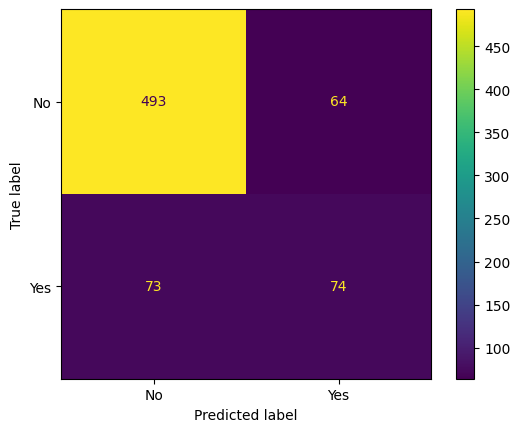

In [109]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["No", "Yes"],
)

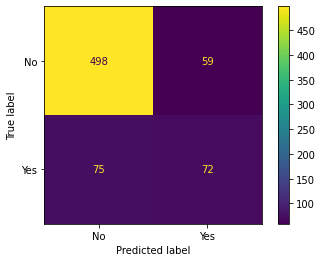

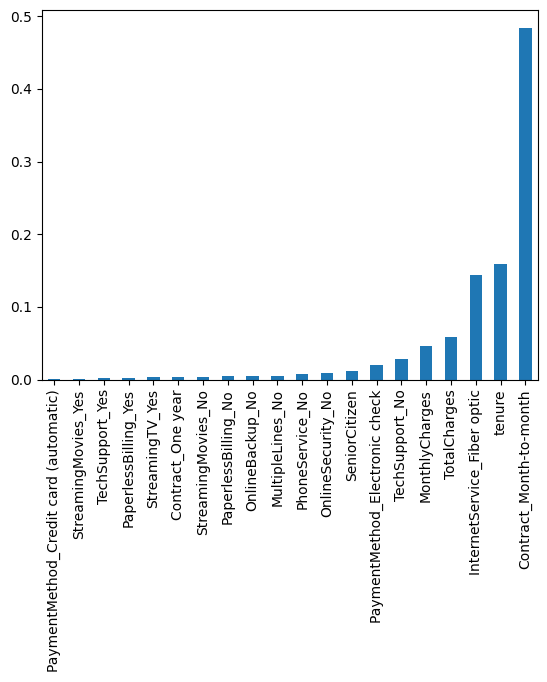

In [132]:

importances = pd.Series(dt.feature_importances_, index=X.columns)
importances= importances.sort_values()


importances.tail(20).plot(kind="bar")
plt.tick_params(axis="x", rotation=90)
plt.show()

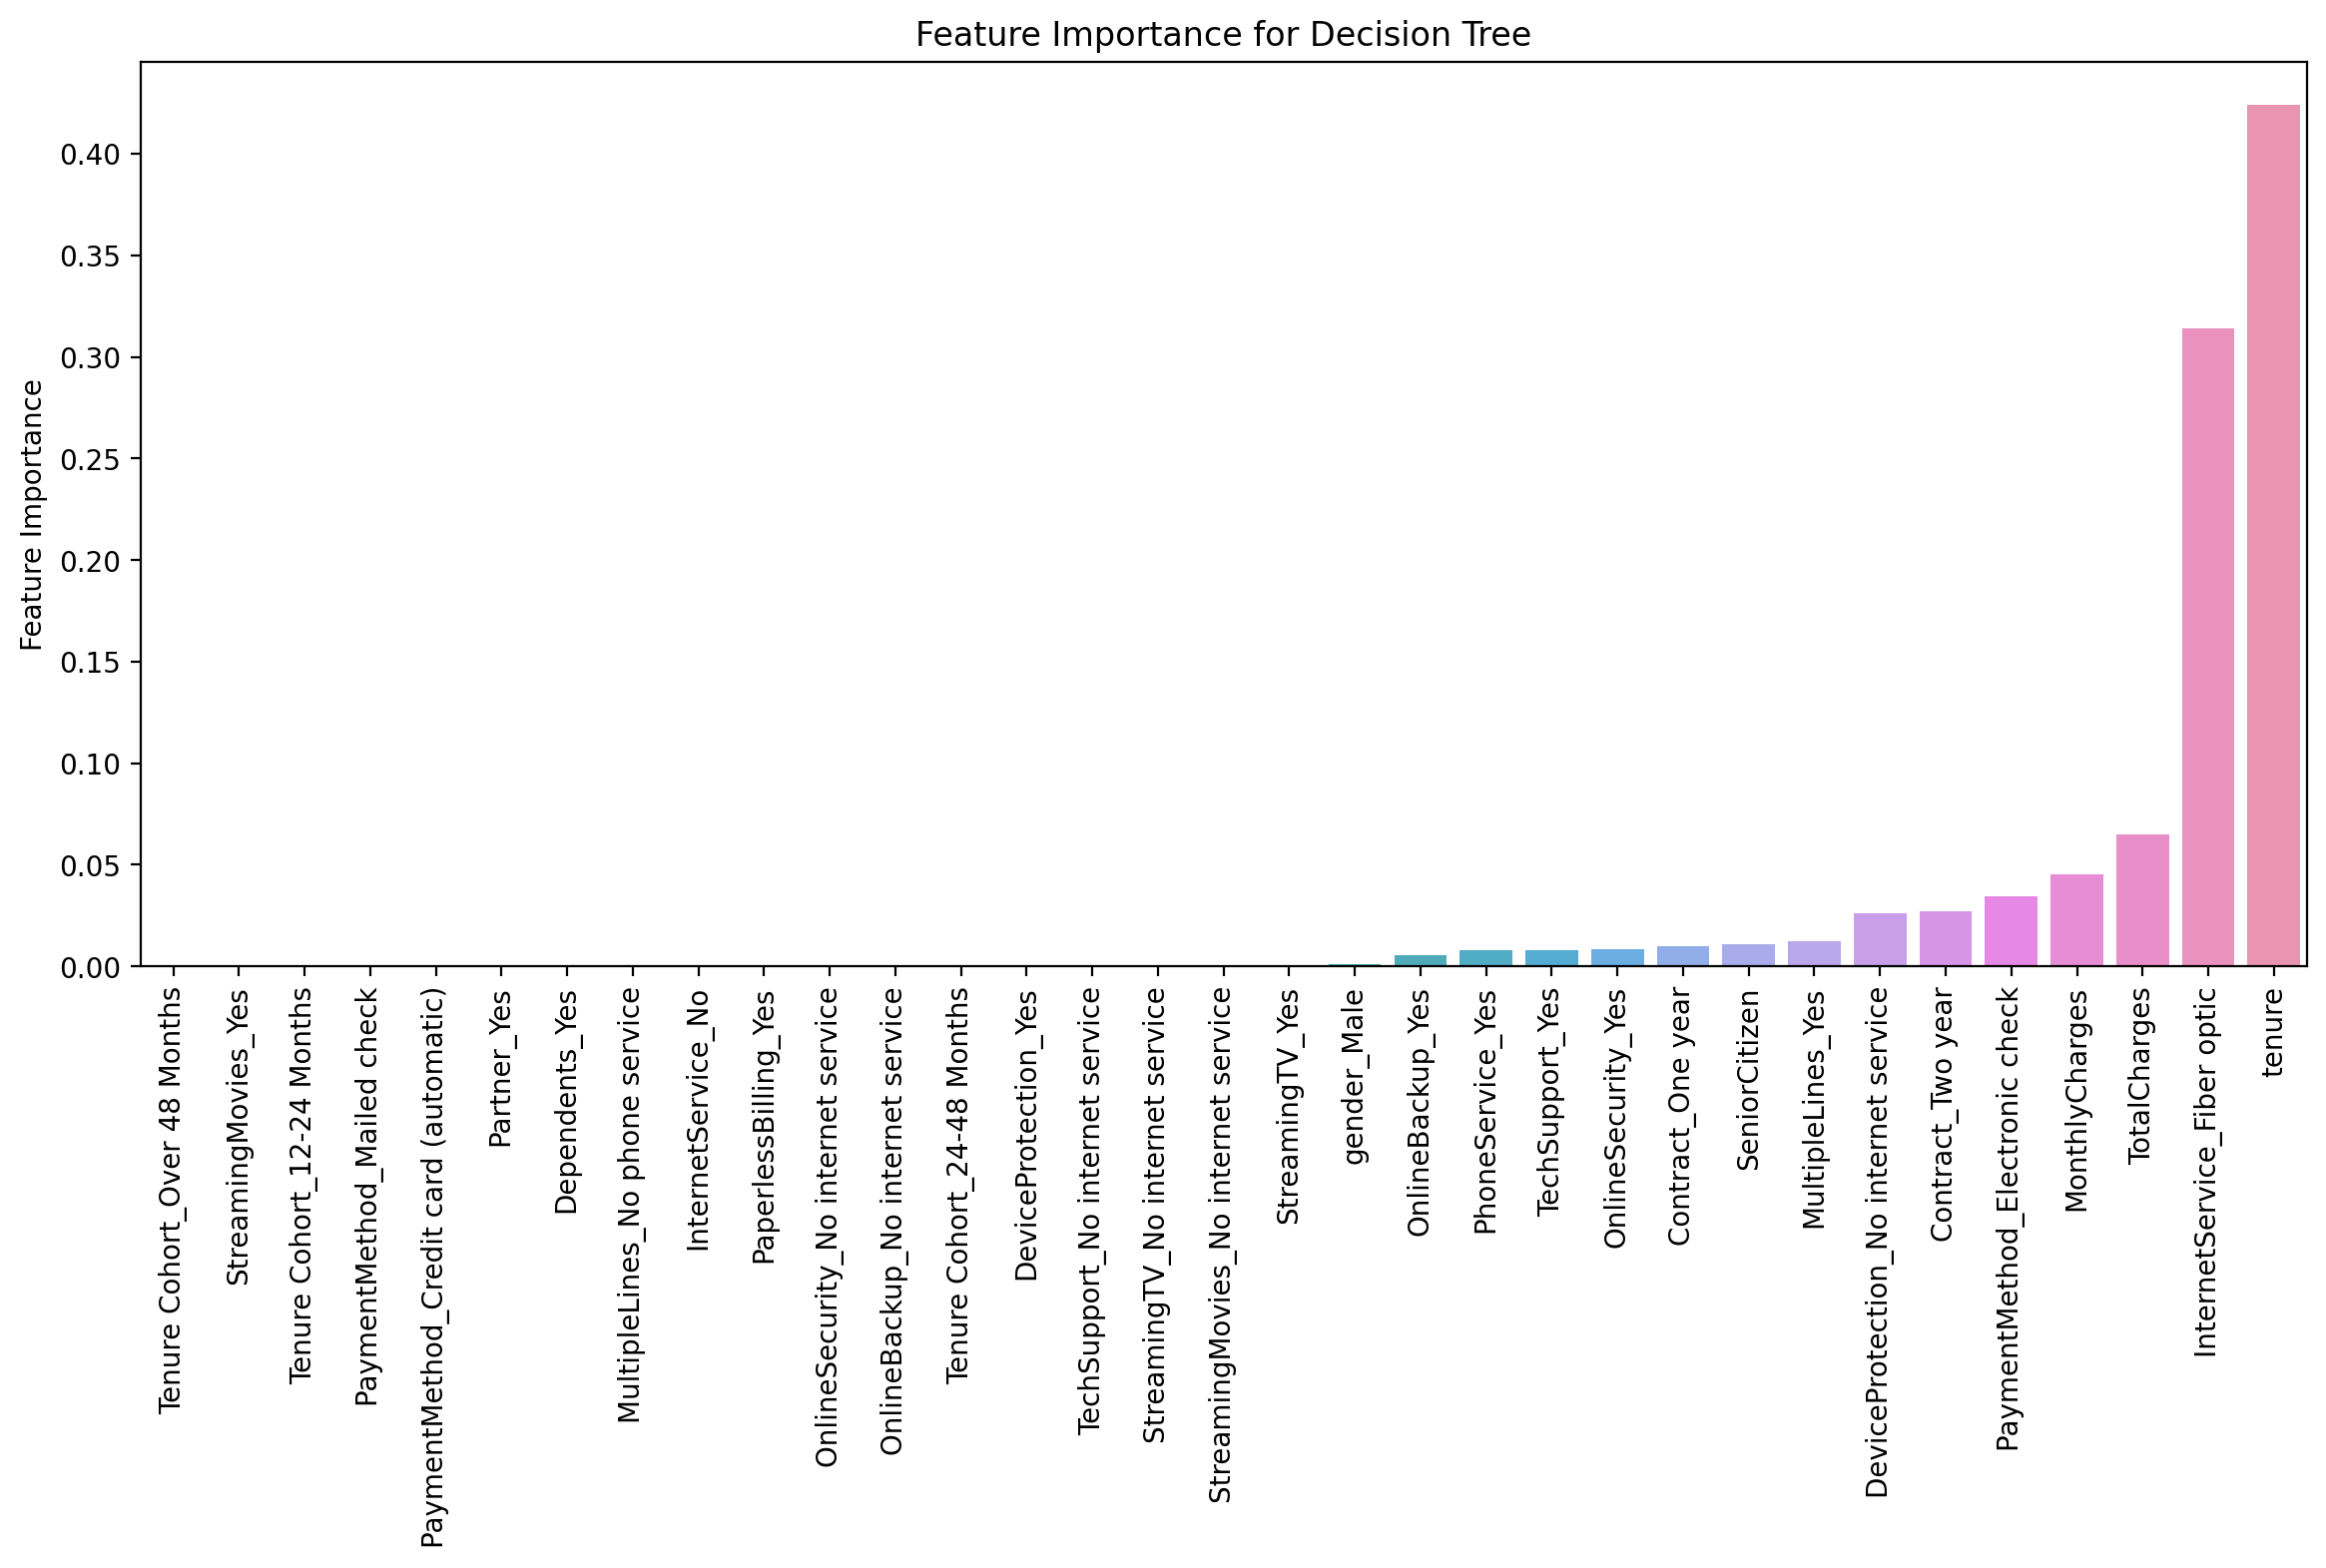

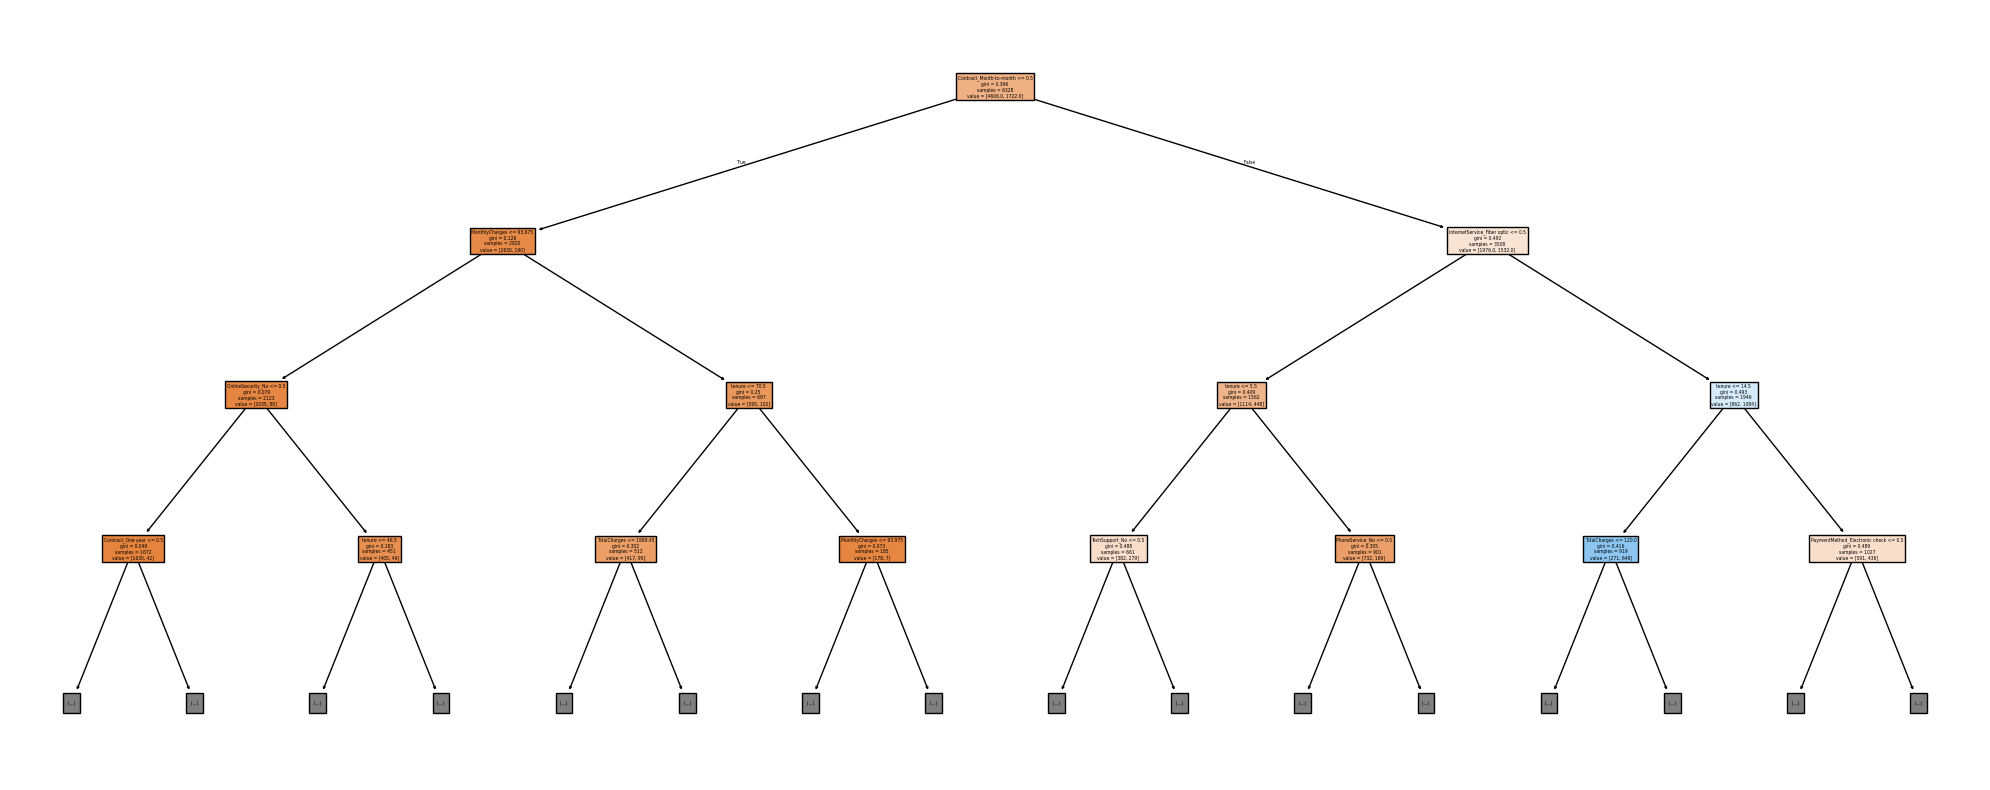

In [143]:


fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=X.columns,
    filled=True,
    max_depth=3,
    ax=ax,
)
plt.tight_layout()
plt.show()

<img src='hugetree.png'>

## Случайный лес (Random Forest)

**Задание: Создайте модель случайного леса, затем выведите отчёт "classification report" и матрицу ошибок для предсказанных результатов на тестовом наборе данных.**

In [144]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(n_estimators=100, random_state=101, n_jobs=-1)
rf.fit(X_train, y_train)

rf

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


RandomForestClassifier()

In [146]:

y_pred_rf = rf.predict(X_test)


print(classification_report(y_test, y_pred_rf, target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       0.86      0.88      0.87       557
         Yes       0.50      0.46      0.48       147

    accuracy                           0.79       704
   macro avg       0.68      0.67      0.67       704
weighted avg       0.78      0.79      0.79       704



              precision    recall  f1-score   support

          No       0.86      0.89      0.87       557
         Yes       0.52      0.44      0.48       147

    accuracy                           0.80       704
   macro avg       0.69      0.67      0.68       704
weighted avg       0.79      0.80      0.79       704



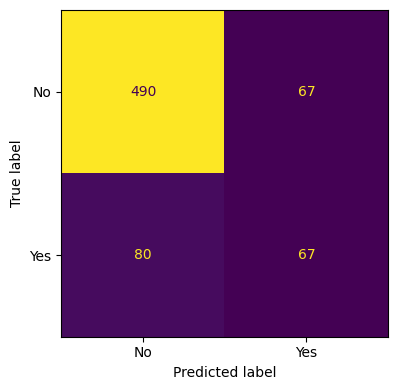

In [147]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=["No", "Yes"],
    colorbar=False,
    ax=ax,
)
plt.tight_layout()
plt.show()

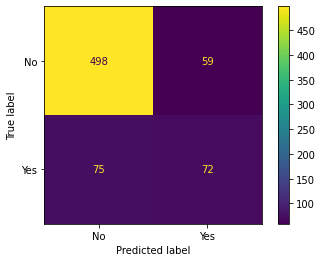

## Расширяемые деревья (Boosted Trees)

**Задание: Создайте модель AdaBoost или Gradient Boosting, затем выведите отчёт "classification report" и матрицу ошибок для предсказанных результатов на тестовом наборе данных.**

  AdaBoost
              precision    recall  f1-score   support

          No       0.88      0.91      0.89       557
         Yes       0.60      0.52      0.56       147

    accuracy                           0.83       704
   macro avg       0.74      0.72      0.73       704
weighted avg       0.82      0.83      0.82       704

  Gradient Boosting
              precision    recall  f1-score   support

          No       0.87      0.90      0.89       557
         Yes       0.57      0.50      0.54       147

    accuracy                           0.82       704
   macro avg       0.72      0.70      0.71       704
weighted avg       0.81      0.82      0.81       704



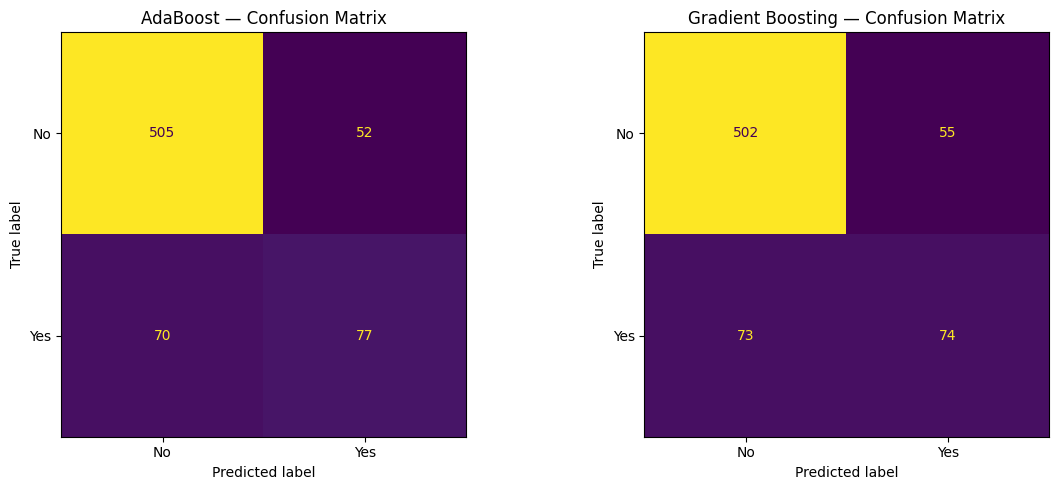

In [149]:
# Напишите Ваш код в этой ячейке
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

models = {
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=101),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=101),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"{'='*45}")
    print(f"  {name}")
    print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["No", "Yes"],
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f"{name} — Confusion Matrix")

plt.tight_layout()
plt.show()

AdaBoostClassifier()

              precision    recall  f1-score   support

          No       0.88      0.90      0.89       557
         Yes       0.60      0.54      0.57       147

    accuracy                           0.83       704
   macro avg       0.74      0.72      0.73       704
weighted avg       0.82      0.83      0.83       704



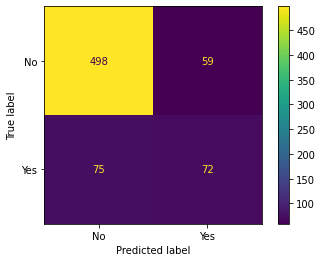

**Задания: Сравнивая результаты, какая модель у Вас работает лучше других?**

In [294]:
# Какая модель дала лучшие результаты и почему? 
# Обязательно выполнить поиск по сетке. Проанализировать лучшие параметры и подобрать действительно достаточные по методу локтя
# Использовать и сравнить все модели и методы из раздела - деревья решения с подбором параметров перебором по сетке и по методу локтя.

In [150]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

param_grids = {
    "Decision Tree": (
        DecisionTreeClassifier(random_state=101),
        {"max_depth": [3, 5, 6, 8, 10], "min_samples_leaf": [1, 5, 10, 20]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=101, n_jobs=-1),
        {"n_estimators": [50, 100, 200], "max_depth": [5, 8, 10, None]}
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=101),
        {"n_estimators": [50, 100, 200], "learning_rate": [0.5, 1.0, 1.5]}
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=101),
        {"n_estimators": [50, 100, 200], "max_depth": [3, 5, 7], "learning_rate": [0.05, 0.1, 0.2]}
    ),
}

best_models = {}
grid_results = []

for name, (model, params) in param_grids.items():
    print(f"Grid Search: {name}...")
    gs = GridSearchCV(model, params, cv=5, scoring="f1", n_jobs=-1)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    grid_results.append({"Model": name, "Best Params": gs.best_params_, "CV F1": round(gs.best_score_, 4)})
    print(f"  Best params: {gs.best_params_}  |  CV F1: {gs.best_score_:.4f}")


Grid Search: Decision Tree...
  Best params: {'max_depth': 5, 'min_samples_leaf': 20}  |  CV F1: 0.5964
Grid Search: Random Forest...
  Best params: {'max_depth': 10, 'n_estimators': 50}  |  CV F1: 0.5897
Grid Search: AdaBoost...
  Best params: {'learning_rate': 0.5, 'n_estimators': 200}  |  CV F1: 0.6086
Grid Search: Gradient Boosting...
  Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}  |  CV F1: 0.5939




  Decision Tree
              precision    recall  f1-score   support

    No Churn       0.87      0.89      0.88       557
       Churn       0.54      0.49      0.51       147

    accuracy                           0.81       704
   macro avg       0.70      0.69      0.70       704
weighted avg       0.80      0.81      0.80       704

  Random Forest
              precision    recall  f1-score   support

    No Churn       0.87      0.91      0.89       557
       Churn       0.60      0.50      0.55       147

    accuracy                           0.83       704
   macro avg       0.74      0.71      0.72       704
weighted avg       0.82      0.83      0.82       704

  AdaBoost
              precision    recall  f1-score   support

    No Churn       0.88      0.91      0.89       557
       Churn       0.61      0.54      0.57       147

    accuracy                           0.83       704
   macro avg       0.74      0.72      0.73       704
weighted avg       0.82      0.

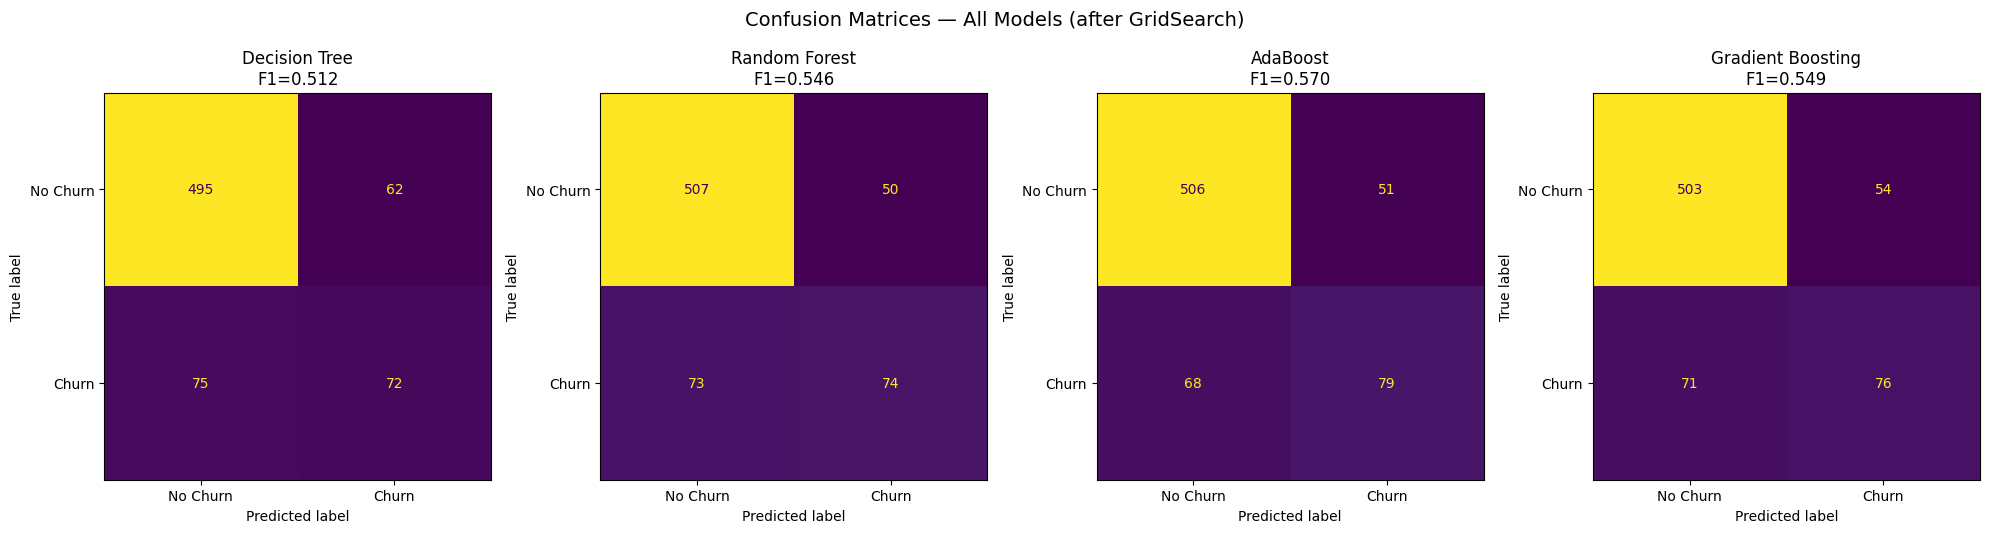

In [151]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
summary = []

for ax, (name, model) in zip(axes, best_models.items()):
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    summary.append({"Model": name, "F1 (Churn)": round(f1, 4)})

    print(f"{'='*45}\n  {name}\n{'='*45}")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["No Churn", "Churn"],
        colorbar=False, ax=ax,
    )
    ax.set_title(f"{name}\nF1={f1:.3f}")

plt.suptitle("Confusion Matrices — All Models (after GridSearch)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

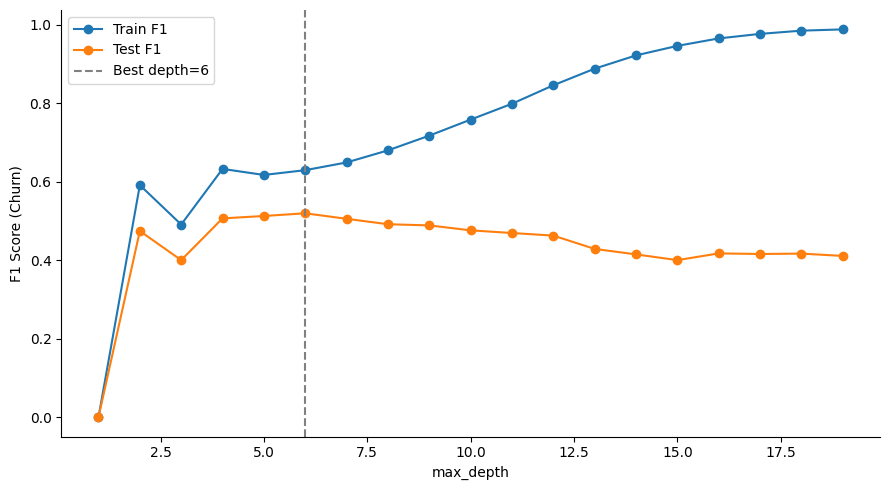

In [155]:
depths = range(1, 20)
f1_train, f1_test = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=101)
    m.fit(X_train, y_train)
    f1_train.append(f1_score(y_train, m.predict(X_train)))
    f1_test.append(f1_score(y_test,  m.predict(X_test)))



fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, f1_train, label="Train F1", marker="o")
ax.plot(depths, f1_test,  label="Test F1",  marker="o")
ax.axvline(
    depths[f1_test.index(max(f1_test))], 
    color="gray", linestyle="--",
    label=f"Best depth={depths[f1_test.index(max(f1_test))]}")

ax.set_xlabel("max_depth")
ax.set_ylabel("F1 Score (Churn)")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

Метод локтя (график):

Вдно, что после глубины дерева = 6 начинается переобучение - F1 на тесте деградирует, на обучающей выборке растет


При max_depth=1 - модель слишком простая, F1=0 (underfitting)

При max_depth=6 - оптимальная точка: Test F1 достигает максимума (~0.52) и дальше только падает

После depth=6 - Train F1 продолжает расти до ~1.0, а Test F1 снижается -> переобучение



── Итоговое сравнение ──
               Model  F1 (Churn)
2           AdaBoost      0.5704
3  Gradient Boosting      0.5487
1      Random Forest      0.5461
0      Decision Tree      0.5125


/var/folders/t1/m2tfv5zd73qfk8f49z94ln3m0000gn/T/ipykernel_49539/1418382707.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x="Model", y="F1 (Churn)", palette="coolwarm_r", ax=ax)


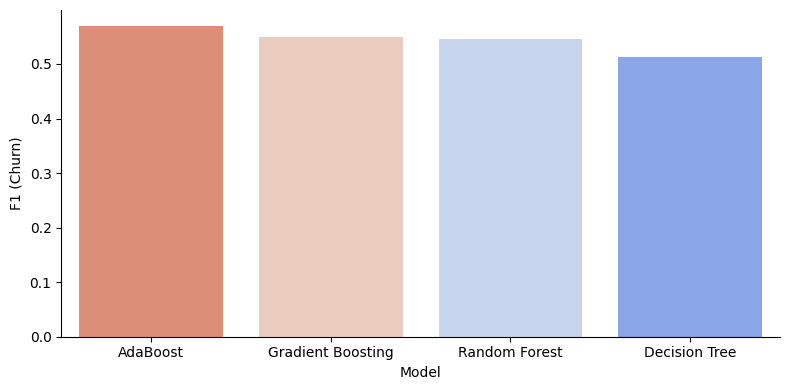

In [158]:
summary_df = pd.DataFrame(summary).sort_values("F1 (Churn)", ascending=False)
print("\n── Итоговое сравнение ──")
print(summary_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=summary_df, x="Model", y="F1 (Churn)", palette="coolwarm_r", ax=ax)

sns.despine()
plt.tight_layout()
plt.show()

Итоговое сравнение моделей:

1. AdaBoost0.5704
2. Gradient Boosting 0.5487
3. Random Forest 0.5461
4. Decision Tree 0.5125

AdaBoost победил — ансамблевые методы бустинга лучше справляются с дисбалансом классов, последовательно исправляя ошибки предыдущих деревьев. Оказался лучше чем Gradient Boosting видимо из-за более простой архитектуры с деревьями глубины 1, что сделало модель более устойчивой при нашем дисбалансе классов



Не самое высокое качество в целом объяснимо сложностью задачи предсказания оттока в целом

### Отличная работа!